In [1]:
!pip install h5py -q
!pip install scikit-image -q
!pip install boto3 -q
!pip install 'meddlr[all]' -q
!pip install skm-tea -q
!pip install torchmetrics==0.11.4 torch==1.13.1+cu117 torchvision==0.14.1+cu117 torchtext==0.14.1 torchaudio==0.13.1 torchdata==0.5.1 --extra-index-url https://download.pytorch.org/whl/cu117


Looking in indexes: https://pypi.org/simple, https://pip.repos.neuron.amazonaws.com, https://download.pytorch.org/whl/cu117


In [2]:
!pip install "numpy<1.24"

Looking in indexes: https://pypi.org/simple, https://pip.repos.neuron.amazonaws.com


In [167]:
import os
import random
import shutil
import time
import warnings
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
from skimage.color import label2rgb
import torch
from tqdm.notebook import tqdm
from sklearn.model_selection import GroupKFold, KFold
import torch.nn as nn
import copy
import boto3
import json
from io import BytesIO
from io import StringIO
from urllib.parse import urlparse
import math
import skm_tea as st
from meddlr.data.data_utils import collect_mask
import timeit
import meddlr.ops as oF
import seaborn
import matplotlib.pyplot as plt

In [168]:
client = boto3.client("s3")

def list_all_objects_in_s3(bucketName, prefixName=None):
    """Get a list of objects in an S3 bucket path.
    @params:
    bucketName : s3 bucket 
    prefixName : s3 prefix to bucket
    returns : list of objects in s3 path
    [example of S3 bucket with prefix f"s3://{bucketName}/{prefix}"]
    """
    if prefixName:
        resp = client.list_objects_v2(Bucket=bucketName, StartAfter=prefixName)
    else:
        resp = client.list_objects_v2(Bucket=bucketName)
    list_of_files=[]
    for obj in resp['Contents']:
        files = bucketName+'/'+obj['Key']
        if prefixName:
            if prefixName in files:
                if prefixName!=files:
                    list_of_files.append(files)
        else:
            list_of_files.append(files)
    return list_of_files

def from_s3_h5(s3_uri: str):
    """
    @params 
    data : file content 
    s3_uri : s3 file path along with name [example of S3 bucket with prefix f"s3://{bucketName}/{prefix}/{fileName.h5}"]
    """
    try:
        
        bytes_ = BytesIO()
        parsed_s3 = urlparse(s3_uri)
        client.download_fileobj(
            Fileobj=bytes_, Bucket=parsed_s3.netloc, Key=parsed_s3.path[1:]
        )
        bytes_.seek(0)
        with h5py.File(bytes_, "w") as f:
            
            echo1 = f["echo1"][()]
            segmentation = f["seg"][()]
    
    except Exception as e: # work on python 3.x
        print("Failed to read numpy array from S3: "+ str(e))
    return echo1, segmentation

def pred_to_categorical(pred_or_logits, activation, channel_dim: int = 1, threshold: float = 0.5):
    """Converts one-hot encoded predictions or logits to category.

    Args:
        pred_or_logits: One-hot encoded predictions or logits. Shape BxCx...
        activation (str): Activation to use.
            Either ``'sigmoid'`` or ``'softmax'`` if ``pred_or_logits`` are logits.
            If `None` or '', assumes that `pred` does not need to be passed through
            activation function. If 'softmax', should include a background class.
        include_background (bool): If `True`, the first slice of class dimension (``C``)
            will not be dropped.
    """
    if activation not in [None, "", "sigmoid", "softmax"]:
        raise ValueError(f"activation '{activation}' not supported'")

    pred = pred_or_logits
    is_ndarray = isinstance(pred, np.ndarray)
    if is_ndarray:
        pred = torch.from_numpy(pred)

    if activation == "sigmoid":
        # TODO: Validate this case.
        out = one_hot_to_categorical(torch.sigmoid(pred) > threshold, channel_dim=channel_dim)
        # out = one_hot_to_categorical(torch.sigmoid(pred), channel_dim=channel_dim)
    elif activation == "softmax":
        out = torch.argmax(pred, dim=channel_dim)
    elif activation in (None, ""):
        # if not activation specified, assume it is one-hot encoded.
        out = one_hot_to_categorical(pred, channel_dim=channel_dim)
    else:
        raise ValueError(f"activation '{activation}' not supported'")

    if is_ndarray:
        out = out.numpy()
    return out

def one_hot_to_categorical(x, channel_dim: int = -1, background=False):
    """Converts one-hot encoded predictions to categorical predictions.

    Args:
        x (torch.Tensor | np.ndarray): One-hot encoded predictions.
        channel_dim (int, optional): Channel dimension.
            Defaults to ``1`` (i.e. ``(B,C,...)``).
        background (bool, optional): If ``True``, assumes index 0 in the
            channel dimension is the background.

    Returns:
        torch.Tensor | np.ndarray: Categorical array or tensor. If ``background=False``,
        the output will be 1-indexed such that ``0`` corresponds to the background.
    """
    is_ndarray = isinstance(x, np.ndarray)
    if is_ndarray:
        x = torch.as_tensor(x)

    if background is not None and background is not False:
        out = torch.argmax(x, channel_dim)
    else:
        out = torch.argmax(x.type(torch.long), dim=channel_dim) + 1
        out = torch.where(x.sum(channel_dim) == 0, torch.tensor([0], device=x.device), out)

    if is_ndarray:
        out = out.numpy()
    return out

def list_all_objects_in_s3(bucketName, prefixName=None):
    """Get a list of objects in an S3 bucket path.
    @params:
    bucketName : s3 bucket 
    prefixName : s3 prefix to bucket
    returns : list of objects in s3 path
    [example of S3 bucket with prefix f"s3://{bucketName}/{prefix}"]
    """
    paginator = client.get_paginator('list_objects_v2')
    if prefixName:
        pages = paginator.paginate(Bucket=bucketName, StartAfter=prefixName)
    else:
        pages = paginator.paginate(Bucket=bucketName)
    list_of_files=[]
    for page in pages:
        for obj in page['Contents']:
            files = bucketName+'/'+obj['Key']
            if prefixName:
                if bucketName+'/'+prefixName in files:
                    if bucketName+'/'+prefixName+'/' !=files:
                        list_of_files.append(files)
            else:
                list_of_files.append(files)
    return list_of_files

In [169]:
s3 = boto3.resource("s3")
def read_file_from_s3(bucket, file):
    try:
        obj = s3.Object(bucket, file)
        data = obj.get()["Body"]
        
    except Exception as e: # work on python 3.x
        print("Failed to read file from S3: "+ str(e))
    return data.read().decode(encoding="utf-8")

In [170]:
df_test = pd.read_csv(StringIO(read_file_from_s3("master-annotation-files", "test_annotations.csv")))
df_test.scan_id.unique()

array(['MTR_173', 'MTR_176', 'MTR_178', 'MTR_188', 'MTR_196', 'MTR_198',
       'MTR_219', 'MTR_221', 'MTR_218', 'MTR_199', 'MTR_224', 'MTR_227',
       'MTR_235', 'MTR_237', 'MTR_240', 'MTR_241', 'MTR_244', 'MTR_248',
       'MTR_005', 'MTR_006', 'MTR_030', 'MTR_034', 'MTR_048', 'MTR_052',
       'MTR_065', 'MTR_066', 'MTR_079', 'MTR_080', 'MTR_096', 'MTR_099',
       'MTR_120', 'MTR_126', 'MTR_144', 'MTR_156', 'MTR_158'],
      dtype=object)

In [171]:
model = st.get_model_from_zoo(
    cfg_or_file="https://huggingface.co/arjundd/skm-tea-models/raw/main/neurips2021/segmentation-models/U-Net_E1/config.yaml",
    weights_path="https://huggingface.co/arjundd/skm-tea-models/resolve/main/neurips2021/segmentation-models/U-Net_E1/model.ckpt",
).eval()

In [172]:
model.cuda()

SkmTeaSemSegModule(
  (model): GeneralizedUNet(
    (down_blocks): ModuleDict(
      (block0): SimpleConvBlockNd(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (block1): SimpleConvBlockNd(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (block2): SimpleConvBlockNd(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
        (4): Batch

In [173]:
from typing import Dict, Iterable, Sequence, Tuple, Union

def collect_mask(
    mask: np.ndarray,
    index: Sequence[Union[int, Sequence[int], int]],
    out_channel_first: bool = True,
):
    """Collect masks by index.

    Collated indices will be summed. For example, `index=(1,(3,4))` will return
    `np.stack(mask[...,1], mask[...,3]+mask[...,4])`.

    TODO: Add support for adding background.

    Args:
        mask (ndarray): A (...)xC array.
        index (Sequence[int]): The index/indices to select in mask.
            If sub-indices are collated, they will be summed.
        out_channel_first (bool, optional): Reorders dimensions of output mask to Cx(...)
    """

    if isinstance(index, int):
        index = (index,)

    if not any(isinstance(idx, Sequence) for idx in index):
        mask = mask[..., index]
    else:
        o_seg = []
        for idx in index:
            c_seg = mask[..., idx]
            if isinstance(idx, Sequence):
                c_seg = np.sum(c_seg, axis=-1)
            o_seg.append(c_seg)
        mask = np.stack(o_seg, axis=-1)

    if out_channel_first:
        last_idx = len(mask.shape) - 1
        mask = np.transpose(mask, (last_idx,) + tuple(range(0, last_idx)))

    return mask

In [174]:
def comp_label(prediction, segmentation, label_num=[1,2,3,4], verbose = True):

    """Predict accuracy per label and identify TP, FP, TN, FN for confusion matrix
    """

    acc = []
    TP, FP, TN, FN = 0, 0, 0, 0

    for i in label_num:
        correct_num = 0
        pixel_num = 0

        true_pixel = (segmentation == i).sum()
        pred_pixel = (prediction == i).sum()
        true_pixel_num = np.count_nonzero(segmentation[segmentation == i])
        correct_num += ((prediction == segmentation) & (segmentation == i)).sum()

        if true_pixel == 0:
            if pred_pixel == 0:
                msg = "no label for segmentation, no label for prediction, true negative, 100% accurate"
                TN += 1
                accuracy_per_label = 1
            else:
                msg = "no label for segmentation, label for prediction, false positive, 0% accurate"
                FP += 1
                accuracy_per_label = 0
        else:
            if pred_pixel == 0:
                msg = "label for segmentation, no label for prediction, false negative, 0% accurate"
                FN += 1
                accuracy_per_label = 0
            else:
                msg = "label for segmentation, label for prediction, true positive, x% accurate"
                TP += 1
                accuracy_per_label = correct_num/true_pixel_num

        if verbose:
            print(msg)
            print("Accuracy for label ", i, " = {:.4f} ".format(accuracy_per_label))

        acc.append(accuracy_per_label)

    if verbose:
        print("confusion matrix for slice ", [TP, FP, TN, FN])

    matrix = [TP, FP, TN, FN]
    return acc, matrix


In [175]:
def make_prediction(scan_id, sl, verbose=True):
    
    t0 = time.time()
    
    echo1, segmentation = from_s3_h5("s3://skm-dataset/skm-tea/qdess/v1-release/image_files/" + scan_id + ".h5")
    num_correct = 0
    num_pixels  = 0
    dice_score  = 0
    
    echo1 = torch.as_tensor(echo1).unsqueeze(0).unsqueeze(0).float()
    echo1 = (echo1 - echo1.mean()) / echo1.std()
    echo1_sl = echo1[..., sl]

    gt_seg_sl_v3 = segmentation[..., sl, :]
    gt_seg_sl_v2 = collect_mask(gt_seg_sl_v3, (0, 1, (4, 5), (2, 3)), out_channel_first=False)
    gt_seg_sl = oF.one_hot_to_categorical(gt_seg_sl_v2, channel_dim=-1)

    echo1_sl = echo1_sl.cuda()

    with torch.no_grad():
        logits = model({"image": echo1_sl})["sem_seg_logits"]
    
    prediction = oF.pred_to_categorical(logits, activation="sigmoid", channel_dim=1).squeeze(0)

    pred = prediction.detach().cpu().numpy()
    
    num_correct += (pred == gt_seg_sl).sum()
    num_pixels += torch.numel(prediction)
    accuracy = num_correct / num_pixels

    accuracy_by_label, matrix_by_slice = comp_label(pred, gt_seg_sl, [1, 2, 3, 4], verbose)

    intersection = np.logical_and(pred, gt_seg_sl)
    
    dice_score = (2 * intersection.sum() + 1e-7) / (pred.sum() + gt_seg_sl.sum() + 1e-7)
    dice_loss = 1 - dice_score
    
    diff = pred == gt_seg_sl
    diff_arr = np.where(diff, 1, 0)
    
    if verbose:

        print(echo1_sl.shape)
        print(np.unique(gt_seg_sl))
        print(f"prediction time per slice: {time.time() - t0}")

        _, axs = plt.subplots(1, 4, figsize=(16, 4))
        plt.suptitle(f"image = {scan_id}, slice = {sl}, loss = {dice_loss:0.4f}, accuracy = {accuracy:0.4f}")
        axs[0].imshow(echo1_sl.detach().cpu().numpy().squeeze(), cmap="bone")
        axs[0].axis("off")
        axs[0].set_title("Image", fontsize=16)

        axs[1].imshow(gt_seg_sl)
        axs[1].axis("off")
        axs[1].set_title("Mask", fontsize=16)
        
        axs[2].imshow(pred)
        axs[2].axis("off")
        axs[2].set_title("Prediction", fontsize=16)
        
        axs[3].imshow(diff_arr, cmap = "binary")
        axs[3].axis("off")
        axs[3].set_title("Difference", fontsize=16)
    
    return gt_seg_sl_v3, gt_seg_sl_v2, gt_seg_sl, pred, prediction, logits, accuracy_by_label, matrix_by_slice

no label for segmentation, label for prediction, false positive, 0% accurate
Accuracy for label  1  = 0.0000 
label for segmentation, label for prediction, true positive, x% accurate
Accuracy for label  2  = 0.9735 
label for segmentation, label for prediction, true positive, x% accurate
Accuracy for label  3  = 0.9536 
label for segmentation, label for prediction, true positive, x% accurate
Accuracy for label  4  = 0.8771 
confusion matrix for slice  [3, 1, 0, 0]
torch.Size([1, 1, 512, 512])
[0 2 3 4]
prediction time per slice: 1.6662604808807373


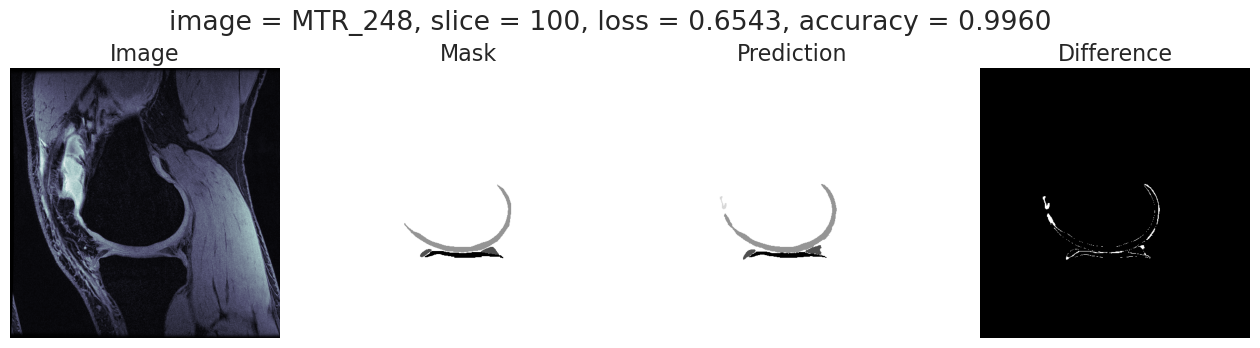

In [176]:
seg_v3, seg_v2, seg, pred, prediction, pred_logits, label_acc, matrix = make_prediction("MTR_248", 100)

In [13]:
label_acc

[0, 0.9734876773711725, 0.9535864978902954, 0.8771454381210478]

In [14]:
matrix

[3, 1, 0, 0]

In [15]:
def perf_on_each_patient(scan_id, sl_min = 0, sl_max = 159, verbose=False):

    per_patient_acc = []
    per_patient_matrix = np.zeros(4)

    print("scan id", scan_id)
        
    for sl in range(sl_min, sl_max):
        
        print("calculating for slice", sl)

        a, b, c, d, e, f, acc_by_label, confusion_matrix = make_prediction(scan_id, sl, verbose)

        per_patient_acc.append(acc_by_label)
        per_patient_matrix = np.add(per_patient_matrix, np.array(confusion_matrix))

    return per_patient_acc, per_patient_matrix

In [16]:
def perf_on_test(scan_id_list, sl_min = 0, sl_max = 159, verbose=False):

    total_acc = []
    total_matrix = np.zeros(4)

    for patient in scan_id_list:
        if patient != 'MTR_178':

            per_patient_acc, per_patient_matrix = perf_on_each_patient(patient, sl_min, sl_max, verbose)

            total_acc.append(per_patient_acc)
            total_matrix = np.add(total_matrix, per_patient_matrix)

    return total_acc, total_matrix

In [111]:
# perf_on_each_patient("MTR_248", 0, 5)

In [110]:
# acc, mat = perf_on_test([df_test.scan_id.unique()[0]], 0, 5, verbose=False)

In [23]:
a = list_all_objects_in_s3('skm-dataset-echo1')

In [125]:
# MTR_178 only has 156 slices
for j in df_test.scan_id.unique():
    ct = 0
    for i in a:
        if i.split("_")[1] == j.split("_")[1]:
            ct += 1
    print(j, ct)

MTR_173 160
MTR_176 160
MTR_178 156
MTR_188 160
MTR_196 160
MTR_198 160
MTR_219 160
MTR_221 160
MTR_218 160
MTR_199 160
MTR_224 160
MTR_227 160
MTR_235 160
MTR_237 160
MTR_240 160
MTR_241 160
MTR_244 160
MTR_248 160
MTR_005 160
MTR_006 160
MTR_030 160
MTR_034 160
MTR_048 160
MTR_052 160
MTR_065 160
MTR_066 160
MTR_079 160
MTR_080 160
MTR_096 160
MTR_099 160
MTR_120 160
MTR_126 160
MTR_144 160
MTR_156 160
MTR_158 160


In [127]:
acc_178, matrix_178 = perf_on_each_patient("MTR_178", 0, 156)

scan id MTR_178
calculating for slice 0
calculating for slice 1
calculating for slice 2
calculating for slice 3
calculating for slice 4
calculating for slice 5
calculating for slice 6
calculating for slice 7
calculating for slice 8
calculating for slice 9
calculating for slice 10
calculating for slice 11
calculating for slice 12
calculating for slice 13
calculating for slice 14
calculating for slice 15
calculating for slice 16
calculating for slice 17
calculating for slice 18
calculating for slice 19
calculating for slice 20
calculating for slice 21
calculating for slice 22
calculating for slice 23
calculating for slice 24
calculating for slice 25
calculating for slice 26
calculating for slice 27
calculating for slice 28
calculating for slice 29
calculating for slice 30
calculating for slice 31
calculating for slice 32
calculating for slice 33
calculating for slice 34
calculating for slice 35
calculating for slice 36
calculating for slice 37
calculating for slice 38
calculating for sli

In [ ]:
acc, mat = perf_on_test(df_test.scan_id.unique(), 0, 159, verbose=False)

scan id MTR_173
calculating for slice 0
calculating for slice 1
calculating for slice 2
calculating for slice 3
calculating for slice 4
calculating for slice 5
calculating for slice 6
calculating for slice 7
calculating for slice 8
calculating for slice 9
calculating for slice 10
calculating for slice 11
calculating for slice 12
calculating for slice 13
calculating for slice 14
calculating for slice 15
calculating for slice 16
calculating for slice 17
calculating for slice 18
calculating for slice 19
calculating for slice 20
calculating for slice 21
calculating for slice 22
calculating for slice 23
calculating for slice 24
calculating for slice 25
calculating for slice 26
calculating for slice 27
calculating for slice 28
calculating for slice 29
calculating for slice 30
calculating for slice 31
calculating for slice 32
calculating for slice 33
calculating for slice 34
calculating for slice 35
calculating for slice 36
calculating for slice 37
calculating for slice 38
calculating for sli

In [128]:
len(acc)

34

In [129]:
len(mat)

4

In [130]:
mat

array([10373.,   822., 10295.,   134.])

In [33]:
np_acc = np.array(acc)

In [35]:
np_acc.shape

(34, 159, 4)

In [55]:
np_acc.mean(axis = 2)

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

In [131]:
acc_all = acc
mat_all = mat

In [132]:
acc_all.append(acc_178)
mat_all = np.add(mat_all, matrix_178)

In [133]:
len(acc_all)

35

In [134]:
len(mat_all)

4

In [135]:
np_acc_all = np.array(acc_all)

/tmp/ipykernel_32037/88854783.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  np_acc_all = np.array(acc_all)


In [137]:
acc_by_patient = np_acc.mean(axis=2).mean(axis=1)

In [138]:
acc_by_patient

array([0.8621982 , 0.92445402, 0.91343902, 0.91094006, 0.89911716,
       0.91572337, 0.90375373, 0.92522828, 0.94145676, 0.89873815,
       0.95103023, 0.86878403, 0.91684263, 0.85855461, 0.88491546,
       0.92375427, 0.90554775, 0.91768709, 0.91279529, 0.84774651,
       0.89650638, 0.89943163, 0.83981386, 0.8915618 , 0.88048236,
       0.91309208, 0.9427924 , 0.90873544, 0.87847874, 0.90067379,
       0.93106261, 0.93066501, 0.8970396 , 0.835897  ])

In [177]:
colors = [(0.267004, 0.004874, 0.329415, 1.0),
 (0.267968, 0.223549, 0.512008, 1.0),
 (0.190631, 0.407061, 0.556089, 1.0),
 (0.20803, 0.718701, 0.472873, 1.0),
 (0.993248, 0.906157, 0.143936, 1.0)]

In [180]:
colors[1][0:3]

(0.267968, 0.223549, 0.512008)

Text(0.5, 0, 'Accuracy')

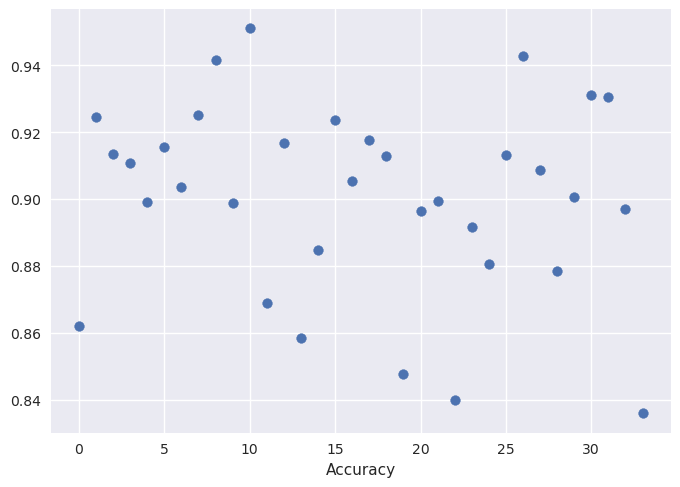

In [151]:
plt.scatter(range(0, len(acc_by_patient)), acc_by_patient)
plt.xlabel("Test Subjects")
plt.xlabel("Accuracy")

In [146]:
acc_by_patient_by_label = np_acc.mean(axis=1)

In [150]:
acc_by_patient_by_label[:,0]

array([0.91727992, 0.94273121, 0.96240229, 0.95656875, 0.93964152,
       0.96159171, 0.91792498, 0.97865052, 0.97841697, 0.97086228,
       0.97961335, 0.94047201, 0.95321291, 0.94542473, 0.92215694,
       0.96759504, 0.92916486, 0.96229536, 0.95361595, 0.97653768,
       0.95763035, 0.9659051 , 0.77475441, 0.94670427, 0.77611043,
       0.95608128, 0.9774144 , 0.87258616, 0.93543449, 0.89794544,
       0.9301943 , 0.95802456, 0.89335481, 0.9303977 ])

In [183]:
b = colors[0]
label_1 = colors[1][0:3]
label_2 = colors[2][0:3]
label_3 = colors[3][0:3]
label_4 = colors[4][0:3]

# plt.plot(x, y, color=[r,g,b])
# plt.annotate(f"({r}, {g}, {b})", (100, y[-1]))

In [209]:
colors[1:5]

[(0.267968, 0.223549, 0.512008, 1.0),
 (0.190631, 0.407061, 0.556089, 1.0),
 (0.20803, 0.718701, 0.472873, 1.0),
 (0.993248, 0.906157, 0.143936, 1.0)]

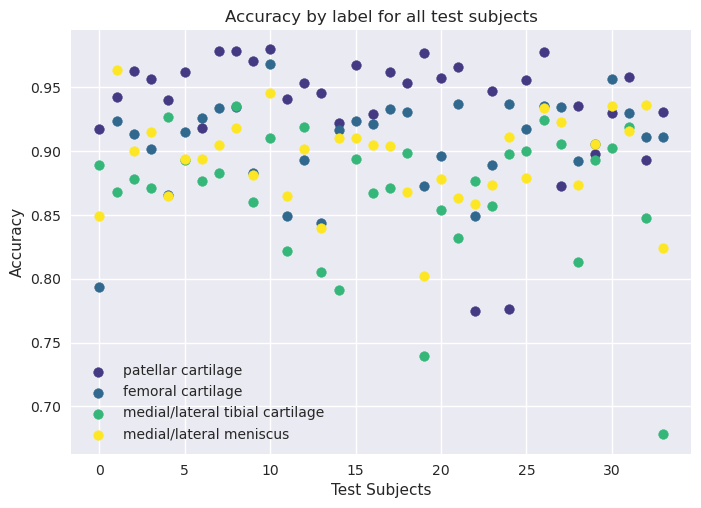

In [218]:
fig = plt.figure()

# plt.scatter(range(0, len(acc_by_patient_by_label)), y, color=c)
    
    
plt.scatter(range(0, len(acc_by_patient_by_label)), acc_by_patient_by_label[:,0], color = label_1, label = "patellar cartilage")
plt.scatter(range(0, len(acc_by_patient_by_label)), acc_by_patient_by_label[:,1], color = label_2, label = "femoral cartilage")
plt.scatter(range(0, len(acc_by_patient_by_label)), acc_by_patient_by_label[:,2], color = label_3, label = "medial/lateral tibial cartilage")
plt.scatter(range(0, len(acc_by_patient_by_label)), acc_by_patient_by_label[:,3], color = label_4, label = "medial/lateral meniscus")

plt.title('Accuracy by label for all test subjects')
plt.xlabel('Test Subjects')
plt.ylabel('Accuracy')

plt.legend(loc = "best")
plt.show()


In [196]:
a, b, c, d = acc_by_patient_by_label[:,0], acc_by_patient_by_label[:,1], acc_by_patient_by_label[:,2], acc_by_patient_by_label[:,3]

In [199]:
labels = ["patellar cartilage", "femoral cartilage", "medial/lateral tibial cartilage", "medial/lateral meniscus"]

In [210]:
colors = [label_1, label_2, label_3, label_4]

In [200]:
df = pd.DataFrame(acc_by_patient_by_label, columns = labels)

In [214]:
import seaborn as sns


In [ ]:
acc_by_slice = np_acc_all.mean(axis=2).mean(axis = 0)

In [86]:
acc_by_slice

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 0.98529412,
       0.99134276, 0.99171631, 0.99122867, 0.98740317, 0.98914855,
       0.97472456, 0.93106724, 0.93028157, 0.95951975, 0.92084226,
       0.92729158, 0.89759123, 0.87724038, 0.89003274, 0.88000498,
       0.87513939, 0.89485133, 0.88827763, 0.87617046, 0.89858445,
       0.87689185, 0.87972292, 0.88698159, 0.89597305, 0.90702683,
       0.88390562, 0.90313159, 0.88385718, 0.91073675, 0.90451943,
       0.91223359, 0.91326658, 0.91252474, 0.91673249, 0.91763556,
       0.90891043, 0.90005788, 0.88744347, 0.89225482, 0.88803835,
       0.8758614 , 0.86359957, 0.86221005, 0.85968877, 0.83673511,
       0.81984112, 0.80345846, 0.77041041, 0.77090988, 0.78820404,
       0.76819669, 0.74744539, 0.73385749, 0.70827436, 0.79356944,
       0.77720881, 0.82529956, 0.86553445, 0.83744493, 0.84498

/tmp/ipykernel_32037/1934535775.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn")


Text(0.5, 1.0, 'Accuracy (averaged between all labels) by slices')

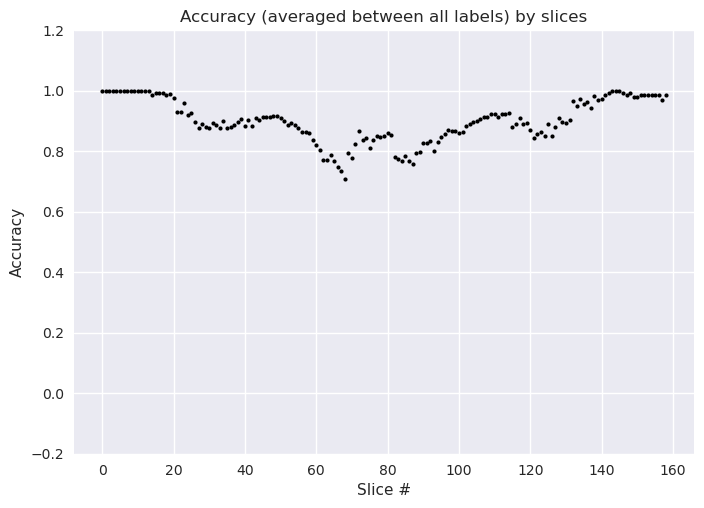

In [113]:
# plt.scatter(range(0, len(acc_by_slice)), acc_by_slice)
plt.plot(range(0, len(acc_by_slice)), acc_by_slice, 'o', color='black', markersize=3);
plt.style.use("seaborn")
plt.ylim(-0.2, 1.2);
plt.xlabel("Slice #")
plt.ylabel("Accuracy")
plt.title("Accuracy (averaged between all labels) by slices")


In [70]:
total_acc = np_acc_all.mean(axis=2).mean(axis=1).mean()

In [71]:
total_acc

0.9008511570924596

In [47]:
acc_by_label = np_acc_all.mean(axis=1)

In [48]:
acc_by_label

array([[0.91727992, 0.79327861, 0.88905902, 0.84917525],
       [0.94273121, 0.9235338 , 0.8676552 , 0.96389588],
       [0.96240229, 0.91301314, 0.87824142, 0.90009923],
       [0.95656875, 0.90133928, 0.87105926, 0.91479295],
       [0.93964152, 0.86540017, 0.92636129, 0.86506567],
       [0.96159171, 0.91481788, 0.89292357, 0.89356034],
       [0.91792498, 0.92614966, 0.87692744, 0.89401285],
       [0.97865052, 0.93408069, 0.8830268 , 0.9051551 ],
       [0.97841697, 0.93432   , 0.93520298, 0.9178871 ],
       [0.97086228, 0.88322183, 0.85972437, 0.8811441 ],
       [0.97961335, 0.96814502, 0.91058874, 0.94577382],
       [0.94047201, 0.84875309, 0.82139311, 0.86451791],
       [0.95321291, 0.89322121, 0.91917164, 0.90176475],
       [0.94542473, 0.84400569, 0.8051071 , 0.83968093],
       [0.92215694, 0.91628953, 0.79090486, 0.91031051],
       [0.96759504, 0.92320579, 0.89369991, 0.91051634],
       [0.92916486, 0.92120687, 0.86704676, 0.9047725 ],
       [0.96229536, 0.93311736,

In [69]:
acc_by_label.mean(axis = 0)

array([0.93613814, 0.90714596, 0.86755998, 0.89256055])

In [90]:
mat.astype(int)

array([10373,   822, 10295,   134])

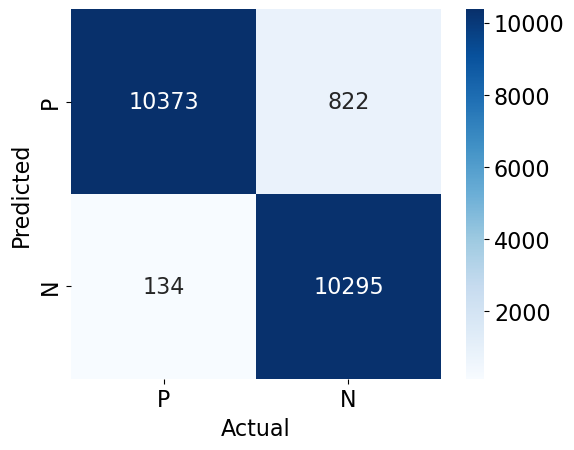

In [93]:
# import seaborn
# import numpy as np
# import matplotlib.pyplot as plt

# data = [[mat[0], mat[1]], [mat[3], mat[2]]]

# ax = seaborn.heatmap(data, xticklabels='PN', yticklabels='PN', annot=True, square=True, cmap='Blues', fmt='g')
# ax.set_xlabel('Actual')
# ax.set_ylabel('Predicted')
# plt.show()

In [117]:
def perf_evaluation(tp, fp, fn, tn):

    # Print the true positive, true negative, false positive, and false negative values
    print("True Positive (TP): ", tp)
    print("True Negative (TN): ", tn)
    print("False Positive (FP): ", fp)
    print("False Negative (FN): ", fn)
     
    # Calculate accuracy
    accuracy = (tp + tn) / (tp + tn + fp + fn)
     
    # Calculate precision
    precision = tp / (tp + fp)
     
    # Calculate recall
    recall = tp / (tp + fn)
     
    # Calculate F1-score
    f1_score = 2 * (precision * recall) / (precision + recall)
     
    # Print the formulas for accuracy, precision, recall, and F1-score
    print("\n\nFormulas:")
    print("Accuracy: (TP + TN) / (TP + TN + FP + FN)")
    print("Precision: TP / (TP + FP)")
    print("Recall: TP / (TP + FN)")
    print("F1-score: 2 * (Precision * Recall) / (Precision + Recall)")
     
    # Print the accuracy, precision, recall, and F1-score
    print("\n\nMetrics:")
    print("Accuracy: ", round(accuracy, 5))
    print("Precision: ", round(precision, 5))
    print("Recall: ", round(recall, 5))
    print("F1-score: ", round(f1_score, 5))

    data = [[tp, fp], [fn, tn]]

    ax = seaborn.heatmap(data, xticklabels='PN', yticklabels='PN', annot=True, square=True, cmap='Blues', fmt='g')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    plt.show()

    return data

True Positive (TP):  10373.0
True Negative (TN):  10295.0
False Positive (FP):  822.0
False Negative (FN):  134.0


Formulas:
Accuracy: (TP + TN) / (TP + TN + FP + FN)
Precision: TP / (TP + FP)
Recall: TP / (TP + FN)
F1-score: 2 * (Precision * Recall) / (Precision + Recall)


Metrics:
Accuracy:  0.95579
Precision:  0.92657
Recall:  0.98725
F1-score:  0.95595


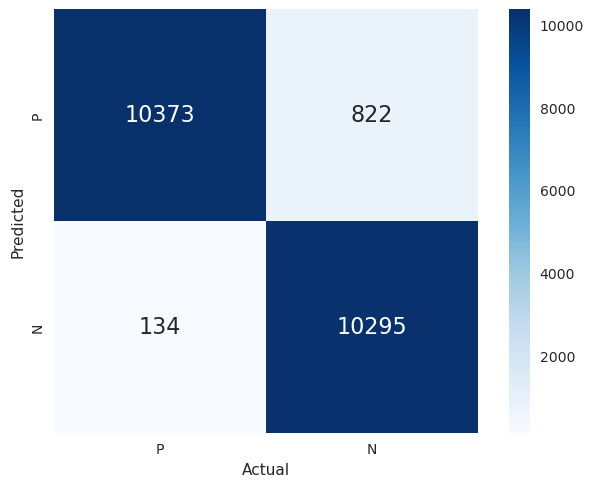

[[10373.0, 822.0], [134.0, 10295.0]]

In [118]:
perf_evaluation(mat[0], mat[1], mat[3], mat[2])
# [TP, FP, TN, FN]
# (tp, fp, fn, tn)

In [119]:
# np.hstack(np_acc)

In [121]:
# x1 = np.arange(9.0).reshape((3, 3))
# x2 = np.arange(3.0)

In [122]:
# x1

In [123]:
# x2

In [124]:
# np.add(x1, x2)